Example code -

* Collaborative filtering (with code for top K recommendation)- https://keras.io/examples/structured_data/collaborative_filtering_movielens/
* Transformer based - https://keras.io/examples/structured_data/movielens_recommendations_transformers/

In [326]:
import math
from zipfile import ZipFile
from urllib.request import urlretrieve
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers.experimental.preprocessing import StringLookup

import more_itertools as mit
from itertools import chain

# Data Preparation

In [327]:
df = pd.read_csv('../../datasets/booking/booking_train_set.csv.gz')

In [328]:
df.drop(columns=['Unnamed: 0'],inplace=True)

In [329]:
# convert int types to str as they are categorical values
df['user_id'] = df['user_id'].apply(lambda x: str(x))
df['city_id'] = df['city_id'].apply(lambda x: str(x))
df['affiliate_id'] = df['affiliate_id'].apply(lambda x: str(x))

In [330]:
# convert to datetime
df['checkin'] = pd.to_datetime(df['checkin']).dt.date
df['checkout'] = pd.to_datetime(df['checkout']).dt.date

# create stay feature
df['stay'] = (df['checkout']-df['checkin']).dt.days
df['stay'] = df['stay'].apply(lambda x: float(x))

# convert back to string
df['checkin'] = df['checkin'].apply(lambda x: str(x))
df['checkout'] = df['checkout'].apply(lambda x: str(x))

In [331]:
%%time
# add prefix to categorical columns that have integer values

df["user_id"] = df["user_id"].apply(lambda x: f"user_{x}")
df["city_id"] = df["city_id"].apply(lambda x: f"city_{x}")
df["affiliate_id"] = df["affiliate_id"].apply(lambda x: f"aff_{x}")
df["utrip_id"] = df["utrip_id"].apply(lambda x: f"trip_{x}")

CPU times: user 668 ms, sys: 31.6 ms, total: 700 ms
Wall time: 702 ms


In [332]:
df.head()

,user_id,checkin,checkout,city_id,device_class,affiliate_id,booker_country,hotel_country,utrip_id,stay
0,user_1006220,2016-04-09,2016-04-11,city_31114,desktop,aff_384,Gondal,Gondal,trip_1006220_1,2.0
1,user_1006220,2016-04-11,2016-04-12,city_39641,desktop,aff_384,Gondal,Gondal,trip_1006220_1,1.0
2,user_1006220,2016-04-12,2016-04-16,city_20232,desktop,aff_384,Gondal,Glubbdubdrib,trip_1006220_1,4.0
3,user_1006220,2016-04-16,2016-04-17,city_24144,desktop,aff_384,Gondal,Gondal,trip_1006220_1,1.0
4,user_1010293,2016-07-09,2016-07-10,city_5325,mobile,aff_359,The Devilfire Empire,Cobra Island,trip_1010293_1,1.0


The `city_id` during a trip become the sequence of items for a particular user i.e the trip.
1. `utrip_id` is our user and `city_id` is our item
2. Number of days spent on a trip is our rating 
3. `checkin` is our reference for time
4. The categorical features that define the user are -
    * user_id
    * device_class
    * affiliate_id
    * booker_country
5. The categorical feature that define the item are -
    * hotel_country

Create a trip specific feature data

In [333]:
users = df[['utrip_id','user_id','device_class','affiliate_id','booker_country']].drop_duplicates(subset=['utrip_id'])
users.shape

(217686, 5)

Create a city to country mapping

In [334]:
city_country = df[['city_id','booker_country']].drop_duplicates(subset=['city_id'])
city_country_dict = dict(zip(city_country.city_id,city_country.booker_country))

## Creating sequences

The average number of stays in a trip is 5.38. So 4 as the number of time steps to predict the next trip seems appropriate

#### 1. Rollup the data at utrip_id level and create list of city_ids, stay and checking dates

In [335]:
%%time
ratings_data = df.groupby('utrip_id')[['city_id','stay','checkin']].agg(list).reset_index()

CPU times: user 13.4 s, sys: 416 ms, total: 13.8 s
Wall time: 13.9 s


In [336]:
ratings_data.head()

,utrip_id,city_id,stay,checkin
0,trip_1000027_1,"[city_8183, city_15626, city_60902, city_30628]","[1.0, 2.0, 2.0, 3.0]","[2016-08-13, 2016-08-14, 2016-08-16, 2016-08-18]"
1,trip_1000033_1,"[city_38677, city_52089, city_21328, city_2748...","[2.0, 1.0, 2.0, 2.0, 3.0]","[2016-04-09, 2016-04-11, 2016-04-12, 2016-04-1..."
2,trip_1000045_1,"[city_64876, city_55128, city_9608, city_31817...","[2.0, 2.0, 2.0, 1.0, 1.0, 2.0, 1.0]","[2016-06-18, 2016-06-20, 2016-06-22, 2016-06-2..."
3,trip_1000083_1,"[city_55990, city_14705, city_35160, city_36063]","[1.0, 1.0, 1.0, 2.0]","[2016-06-13, 2016-06-14, 2016-06-15, 2016-06-16]"
4,trip_100008_1,"[city_11306, city_12096, city_6761, city_6779,...","[3.0, 1.0, 1.0, 2.0, 2.0]","[2016-07-18, 2016-07-21, 2016-07-22, 2016-07-2..."


In [337]:
%%time

sequence_length = 4
step_size = 2

def fillna_list(x,fill_val):
    return pd.Series(x).fillna(fill_val).to_list()

def create_sequences(values, window_size, step_size, fill_na=False):
    rev_windows = list(mit.windowed(reversed(values), n=window_size, step=step_size))
    if fill_na:
        windows = [fillna_list(list(reversed(x)),0) for x in rev_windows]
    else:
        windows = [list(reversed(x)) for x in rev_windows]
    return windows

ratings_data['city_id_w'] = ratings_data.city_id.apply(
    lambda ids: create_sequences(ids, sequence_length, step_size, fill_na=True)
)

ratings_data['stay_w'] = ratings_data.stay.apply(
    lambda ids: create_sequences(ids, sequence_length, step_size, fill_na=True)
)

ratings_data['checkin_w'] = ratings_data.checkin.apply(
    lambda ids: create_sequences(ids, sequence_length, step_size, fill_na=True)
)

#del ratings_data["timestamps"]

CPU times: user 3min 20s, sys: 2.75 s, total: 3min 22s
Wall time: 3min 21s


In [338]:
ratings_data.head()

,utrip_id,city_id,stay,checkin,city_id_w,stay_w,checkin_w
0,trip_1000027_1,"[city_8183, city_15626, city_60902, city_30628]","[1.0, 2.0, 2.0, 3.0]","[2016-08-13, 2016-08-14, 2016-08-16, 2016-08-18]","[[city_8183, city_15626, city_60902, city_30628]]","[[1.0, 2.0, 2.0, 3.0]]","[[2016-08-13, 2016-08-14, 2016-08-16, 2016-08-..."
1,trip_1000033_1,"[city_38677, city_52089, city_21328, city_2748...","[2.0, 1.0, 2.0, 2.0, 3.0]","[2016-04-09, 2016-04-11, 2016-04-12, 2016-04-1...","[[city_52089, city_21328, city_27485, city_386...","[[1.0, 2.0, 2.0, 3.0], [0.0, 2.0, 1.0, 2.0]]","[[2016-04-11, 2016-04-12, 2016-04-14, 2016-04-..."
2,trip_1000045_1,"[city_64876, city_55128, city_9608, city_31817...","[2.0, 2.0, 2.0, 1.0, 1.0, 2.0, 1.0]","[2016-06-18, 2016-06-20, 2016-06-22, 2016-06-2...","[[city_31817, city_36170, city_58178, city_360...","[[1.0, 1.0, 2.0, 1.0], [2.0, 2.0, 1.0, 1.0], [...","[[2016-06-24, 2016-06-25, 2016-06-26, 2016-06-..."
3,trip_1000083_1,"[city_55990, city_14705, city_35160, city_36063]","[1.0, 1.0, 1.0, 2.0]","[2016-06-13, 2016-06-14, 2016-06-15, 2016-06-16]","[[city_55990, city_14705, city_35160, city_360...","[[1.0, 1.0, 1.0, 2.0]]","[[2016-06-13, 2016-06-14, 2016-06-15, 2016-06-..."
4,trip_100008_1,"[city_11306, city_12096, city_6761, city_6779,...","[3.0, 1.0, 1.0, 2.0, 2.0]","[2016-07-18, 2016-07-21, 2016-07-22, 2016-07-2...","[[city_12096, city_6761, city_6779, city_65690...","[[1.0, 1.0, 2.0, 2.0], [0.0, 3.0, 1.0, 1.0]]","[[2016-07-21, 2016-07-22, 2016-07-23, 2016-07-..."


In [339]:
%%time

# 1.Explode seuqences into different rows
ratings_data_city = ratings_data[["utrip_id", "city_id_w"]].explode("city_id_w", ignore_index=True)
ratings_data_rating = ratings_data[["utrip_id", "stay_w"]].explode("stay_w", ignore_index=True)
ratings_data_time = ratings_data[["utrip_id", "checkin_w"]].explode("checkin_w", ignore_index=True)

# 2.Combine and convert list to comma seperated strings
ratings_data_comb = pd.concat([ratings_data_city, 
                                      ratings_data_rating[['stay_w']],
                                      ratings_data_time[['checkin_w']]], axis=1)

ratings_data_comb['seq_city_ids'] = ratings_data_comb['city_id_w'].apply(lambda x: ",".join([str(v) for v in x]))
ratings_data_comb['seq_ratings'] = ratings_data_comb['stay_w'].apply(lambda x: ",".join([str(v) for v in x]))
ratings_data_comb['seq_time'] = ratings_data_comb['checkin_w'].apply(lambda x: ",".join([str(v) for v in x]))

# 3.Concat the non time series data
ratings_data_transformed = pd.merge(ratings_data_comb[['utrip_id','seq_city_ids','seq_ratings','seq_time']],
                                    users,on='utrip_id',how='left')
                               

CPU times: user 2.29 s, sys: 78.1 ms, total: 2.37 s
Wall time: 2.38 s


In [340]:
ratings_data_transformed.head()

,utrip_id,seq_city_ids,seq_ratings,seq_time,user_id,device_class,affiliate_id,booker_country
0,trip_1000027_1,"city_8183,city_15626,city_60902,city_30628","1.0,2.0,2.0,3.0","2016-08-13,2016-08-14,2016-08-16,2016-08-18",user_1000027,desktop,aff_7168,Elbonia
1,trip_1000033_1,"city_52089,city_21328,city_27485,city_38677","1.0,2.0,2.0,3.0","2016-04-11,2016-04-12,2016-04-14,2016-04-16",user_1000033,mobile,aff_359,Gondal
2,trip_1000033_1,"0,city_38677,city_52089,city_21328","0.0,2.0,1.0,2.0","0,2016-04-09,2016-04-11,2016-04-12",user_1000033,mobile,aff_359,Gondal
3,trip_1000045_1,"city_31817,city_36170,city_58178,city_36063","1.0,1.0,2.0,1.0","2016-06-24,2016-06-25,2016-06-26,2016-06-28",user_1000045,desktop,aff_2790,The Devilfire Empire
4,trip_1000045_1,"city_55128,city_9608,city_31817,city_36170","2.0,2.0,1.0,1.0","2016-06-20,2016-06-22,2016-06-24,2016-06-25",user_1000045,desktop,aff_2790,The Devilfire Empire


In [341]:
random_selection = np.random.rand(len(ratings_data_transformed.index)) <= 0.85
train_data = ratings_data_transformed[random_selection]
test_data = ratings_data_transformed[~random_selection]

train_data.to_csv("train_data.csv", index=False, sep="|", header=False)
test_data.to_csv("test_data.csv", index=False, sep="|", header=False)

In [356]:
print (['a','b']+['0'])

['a', 'b', '0']


# Define metadata

In [357]:
CSV_HEADER = list(ratings_data_transformed.columns)

CATEGORICAL_FEATURES_WITH_VOCABULARY = {
    'utrip_id': list(users.utrip_id.unique())+['0'],
    'user_id': list(users.user_id.unique()),
    'city_id': list(df.city_id.unique())+['0'],
    'device_class': list(users.device_class.unique()),
    'affiliate_id': list(users.affiliate_id.unique()),
    'booker_country': list(users.booker_country.unique()),
}

USER_FEATURES = ['user_id','device_class','affiliate_id','booker_country']

#MOVIE_FEATURES = ["genres"]

In [358]:
def get_dataset_from_csv(csv_file_path, shuffle=False, batch_size=128):
    def process(features):
        city_ids_string = features["seq_city_ids"]
        sequence_city_ids = tf.strings.split(city_ids_string, ",").to_tensor()

        # The last movie id in the sequence is the target movie.
        features["target_city_id"] = sequence_city_ids[:, -1]
        features["seq_city_ids"] = sequence_city_ids[:, :-1]

        ratings_string = features["seq_ratings"]
        sequence_ratings = tf.strings.to_number(
            tf.strings.split(ratings_string, ","), tf.dtypes.float32
        ).to_tensor()

        # The last rating in the sequence is the target for the model to predict.
        target = sequence_ratings[:, -1]
        features["seq_ratings"] = sequence_ratings[:, :-1]

        return features, target

    dataset = tf.data.experimental.make_csv_dataset(
        csv_file_path,
        batch_size=batch_size,
        column_names=CSV_HEADER,
        num_epochs=1,
        header=False,
        field_delim="|",
        shuffle=shuffle,
    ).map(process)

    return dataset

In [359]:
def create_model_inputs():
    return {
        "utrip_id": layers.Input(name="utrip_id", shape=(1,), dtype=tf.string),
        "seq_city_ids": layers.Input(
            name="seq_city_ids", shape=(sequence_length - 1,), dtype=tf.string
        ),
        "target_city_id": layers.Input(
            name="target_city_id", shape=(1,), dtype=tf.string
        ),
        "seq_ratings": layers.Input(
            name="seq_ratings", shape=(sequence_length - 1,), dtype=tf.float32
        ),
        "user_id": layers.Input(name="user_id", shape=(1,), dtype=tf.string),
        "device_class": layers.Input(name="device_class", shape=(1,), dtype=tf.string),
        "affiliate_id": layers.Input(name="affiliate_id", shape=(1,), dtype=tf.string),
        "booker_country": layers.Input(name="booker_country", shape=(1,), dtype=tf.string),
    }

In [360]:
def encode_input_features(
    inputs,
    include_user_id=True,
    include_user_features=True,
    include_item_features=True,
):

    encoded_transformer_features = []
    encoded_other_features = []

    other_feature_names = []
    if include_user_id:
        other_feature_names.append("utrip_id")
    if include_user_features:
        other_feature_names.extend(USER_FEATURES)

    ## Encode user features
    for feature_name in other_feature_names:
        # Convert the string input values into integer indices.
        vocabulary = CATEGORICAL_FEATURES_WITH_VOCABULARY[feature_name]
        idx = StringLookup(vocabulary=vocabulary, mask_token=None, num_oov_indices=0)(
            inputs[feature_name]
        )
        # Compute embedding dimensions
        embedding_dims = int(math.sqrt(len(vocabulary)))
        # Create an embedding layer with the specified dimensions.
        embedding_encoder = layers.Embedding(
            input_dim=len(vocabulary),
            output_dim=embedding_dims,
            name=f"{feature_name}_embedding",
        )
        # Convert the index values to embedding representations.
        encoded_other_features.append(embedding_encoder(idx))

    ## Create a single embedding vector for the user features
    if len(encoded_other_features) > 1:
        encoded_other_features = layers.concatenate(encoded_other_features)
    elif len(encoded_other_features) == 1:
        encoded_other_features = encoded_other_features[0]
    else:
        encoded_other_features = None

    ## Create a city embedding encoder
    city_vocabulary = CATEGORICAL_FEATURES_WITH_VOCABULARY["city_id"]
    city_embedding_dims = int(math.sqrt(len(city_vocabulary)))
    # Create a lookup to convert string values to integer indices.
    city_index_lookup = StringLookup(
        vocabulary=city_vocabulary,
        mask_token=None,
        num_oov_indices=0,
        name="city_index_lookup",
    )
    # Create an embedding layer with the specified dimensions.
    city_embedding_encoder = layers.Embedding(
        input_dim=len(city_vocabulary),
        output_dim=city_embedding_dims,
        name=f"city_embedding",
    )
    '''
    # Create a vector lookup for movie genres.
    genre_vectors = movies[genres].to_numpy()
    movie_genres_lookup = layers.Embedding(
        input_dim=genre_vectors.shape[0],
        output_dim=genre_vectors.shape[1],
        embeddings_initializer=tf.keras.initializers.Constant(genre_vectors),
        trainable=False,
        name="genres_vector",
    )
    '''
    # Create a processing layer for genres.
    city_embedding_processor = layers.Dense(
        units=city_embedding_dims,
        activation="relu",
        name="process_city_embedding_with_country",
    )
    
    ## Create a booker_country embedding encoder
    booker_country_vocabulary = CATEGORICAL_FEATURES_WITH_VOCABULARY["booker_country"]
    booker_country_embedding_dims = int(math.sqrt(len(booker_country_vocabulary)))
    # Create a lookup to convert string values to integer indices.
    booker_country_index_lookup = StringLookup(
        vocabulary=booker_country_vocabulary,
        mask_token=None,
        num_oov_indices=0,
        name="booker_country_index_lookup",
    )
    # Create an embedding layer with the specified dimensions.
    booker_country_embedding_encoder = layers.Embedding(
        input_dim=len(booker_country_vocabulary),
        output_dim=booker_country_embedding_dims,
        name="booker_country_embedding",
    )


    ## Define a function to encode a given city id.
    def encode_city(city_id):
        # Convert the string input values into integer indices.
        city_idx = city_index_lookup(city_id)
        city_embedding = city_embedding_encoder(city_idx)
        encoded_city = city_embedding
        if include_item_features:
            #movie_genres_vector = movie_genres_lookup(movie_idx)
            booker_country = city_country_dict(city_id)
            booker_country_idx = booker_country_index_lookup(booker_country)
            booker_country_embedding = booker_country_embedding_encoder(booker_country)
            encoded_city = city_embedding_processor(
                layers.concatenate([city_embedding, booker_country_embedding])
            )
        return encoded_city

    ## Encoding target_city_id
    target_city_id = inputs["target_city_id"]
    encoded_target_city = encode_city(target_city_id)

    ## Encoding sequence city_ids.
    sequence_city_ids = inputs["seq_city_ids"]
    encoded_sequence_city = encode_city(sequence_city_ids)
    # Create positional embedding.
    position_embedding_encoder = layers.Embedding(
        input_dim=sequence_length,
        output_dim=city_embedding_dims,
        name="position_embedding",
    )
    positions = tf.range(start=0, limit=sequence_length - 1, delta=1)
    encodded_positions = position_embedding_encoder(positions)
    # Retrieve sequence ratings to incorporate them into the encoding of the movie.
    sequence_ratings = tf.expand_dims(inputs["seq_ratings"], -1)
    # Add the positional encoding to the movie encodings and multiply them by rating.
    encoded_sequence_city_with_poistion_and_rating = layers.Multiply()(
        [(encoded_sequence_city + encodded_positions), sequence_ratings]
    )

    # Construct the transformer inputs.
    for encoded_city in tf.unstack(
        encoded_sequence_city_with_poistion_and_rating, axis=1
    ):
        encoded_transformer_features.append(tf.expand_dims(encoded_city, 1))
    encoded_transformer_features.append(encoded_target_city)

    encoded_transformer_features = layers.concatenate(
        encoded_transformer_features, axis=1
    )

    return encoded_transformer_features, encoded_other_features


In [361]:
include_user_id = False
include_user_features = True
include_item_features = False

hidden_units = [256, 128]
dropout_rate = 0.1
num_heads = 3


def create_model():
    inputs = create_model_inputs()
    transformer_features, other_features = encode_input_features(
        inputs, include_user_id, include_user_features, include_item_features
    )

    # Create a multi-headed attention layer.
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=transformer_features.shape[2], dropout=dropout_rate
    )(transformer_features, transformer_features)

    # Transformer block.
    attention_output = layers.Dropout(dropout_rate)(attention_output)
    x1 = layers.Add()([transformer_features, attention_output])
    x1 = layers.LayerNormalization()(x1)
    x2 = layers.LeakyReLU()(x1)
    x2 = layers.Dense(units=x2.shape[-1])(x2)
    x2 = layers.Dropout(dropout_rate)(x2)
    transformer_features = layers.Add()([x1, x2])
    transformer_features = layers.LayerNormalization()(transformer_features)
    features = layers.Flatten()(transformer_features)

    # Included the other features.
    if other_features is not None:
        features = layers.concatenate(
            [features, layers.Reshape([other_features.shape[-1]])(other_features)]
        )

    # Fully-connected layers.
    for num_units in hidden_units:
        features = layers.Dense(num_units)(features)
        features = layers.BatchNormalization()(features)
        features = layers.LeakyReLU()(features)
        features = layers.Dropout(dropout_rate)(features)

    outputs = layers.Dense(units=1)(features)
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model


model = create_model()

Note: `MultiHeadAttention` throws an error if tensorflow version is not 2.4.0rc4. Do `pip3 install tensorflow==2.4.0rc4` and restart the kernel to remove the error

In [362]:
# Compile the model.
model.compile(
    optimizer=keras.optimizers.Adagrad(learning_rate=0.01),
    loss=keras.losses.MeanSquaredError(),
    metrics=[keras.metrics.MeanAbsoluteError()],
)


In [363]:
print(model.summary())

Model: "model_11"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
seq_city_ids (InputLayer)       [(None, 3)]          0                                            
__________________________________________________________________________________________________
city_index_lookup (StringLookup multiple             0           target_city_id[0][0]             
                                                                 seq_city_ids[0][0]               
__________________________________________________________________________________________________
city_embedding (Embedding)      multiple             7940498     city_index_lookup[0][0]          
                                                                 city_index_lookup[1][0]          
___________________________________________________________________________________________

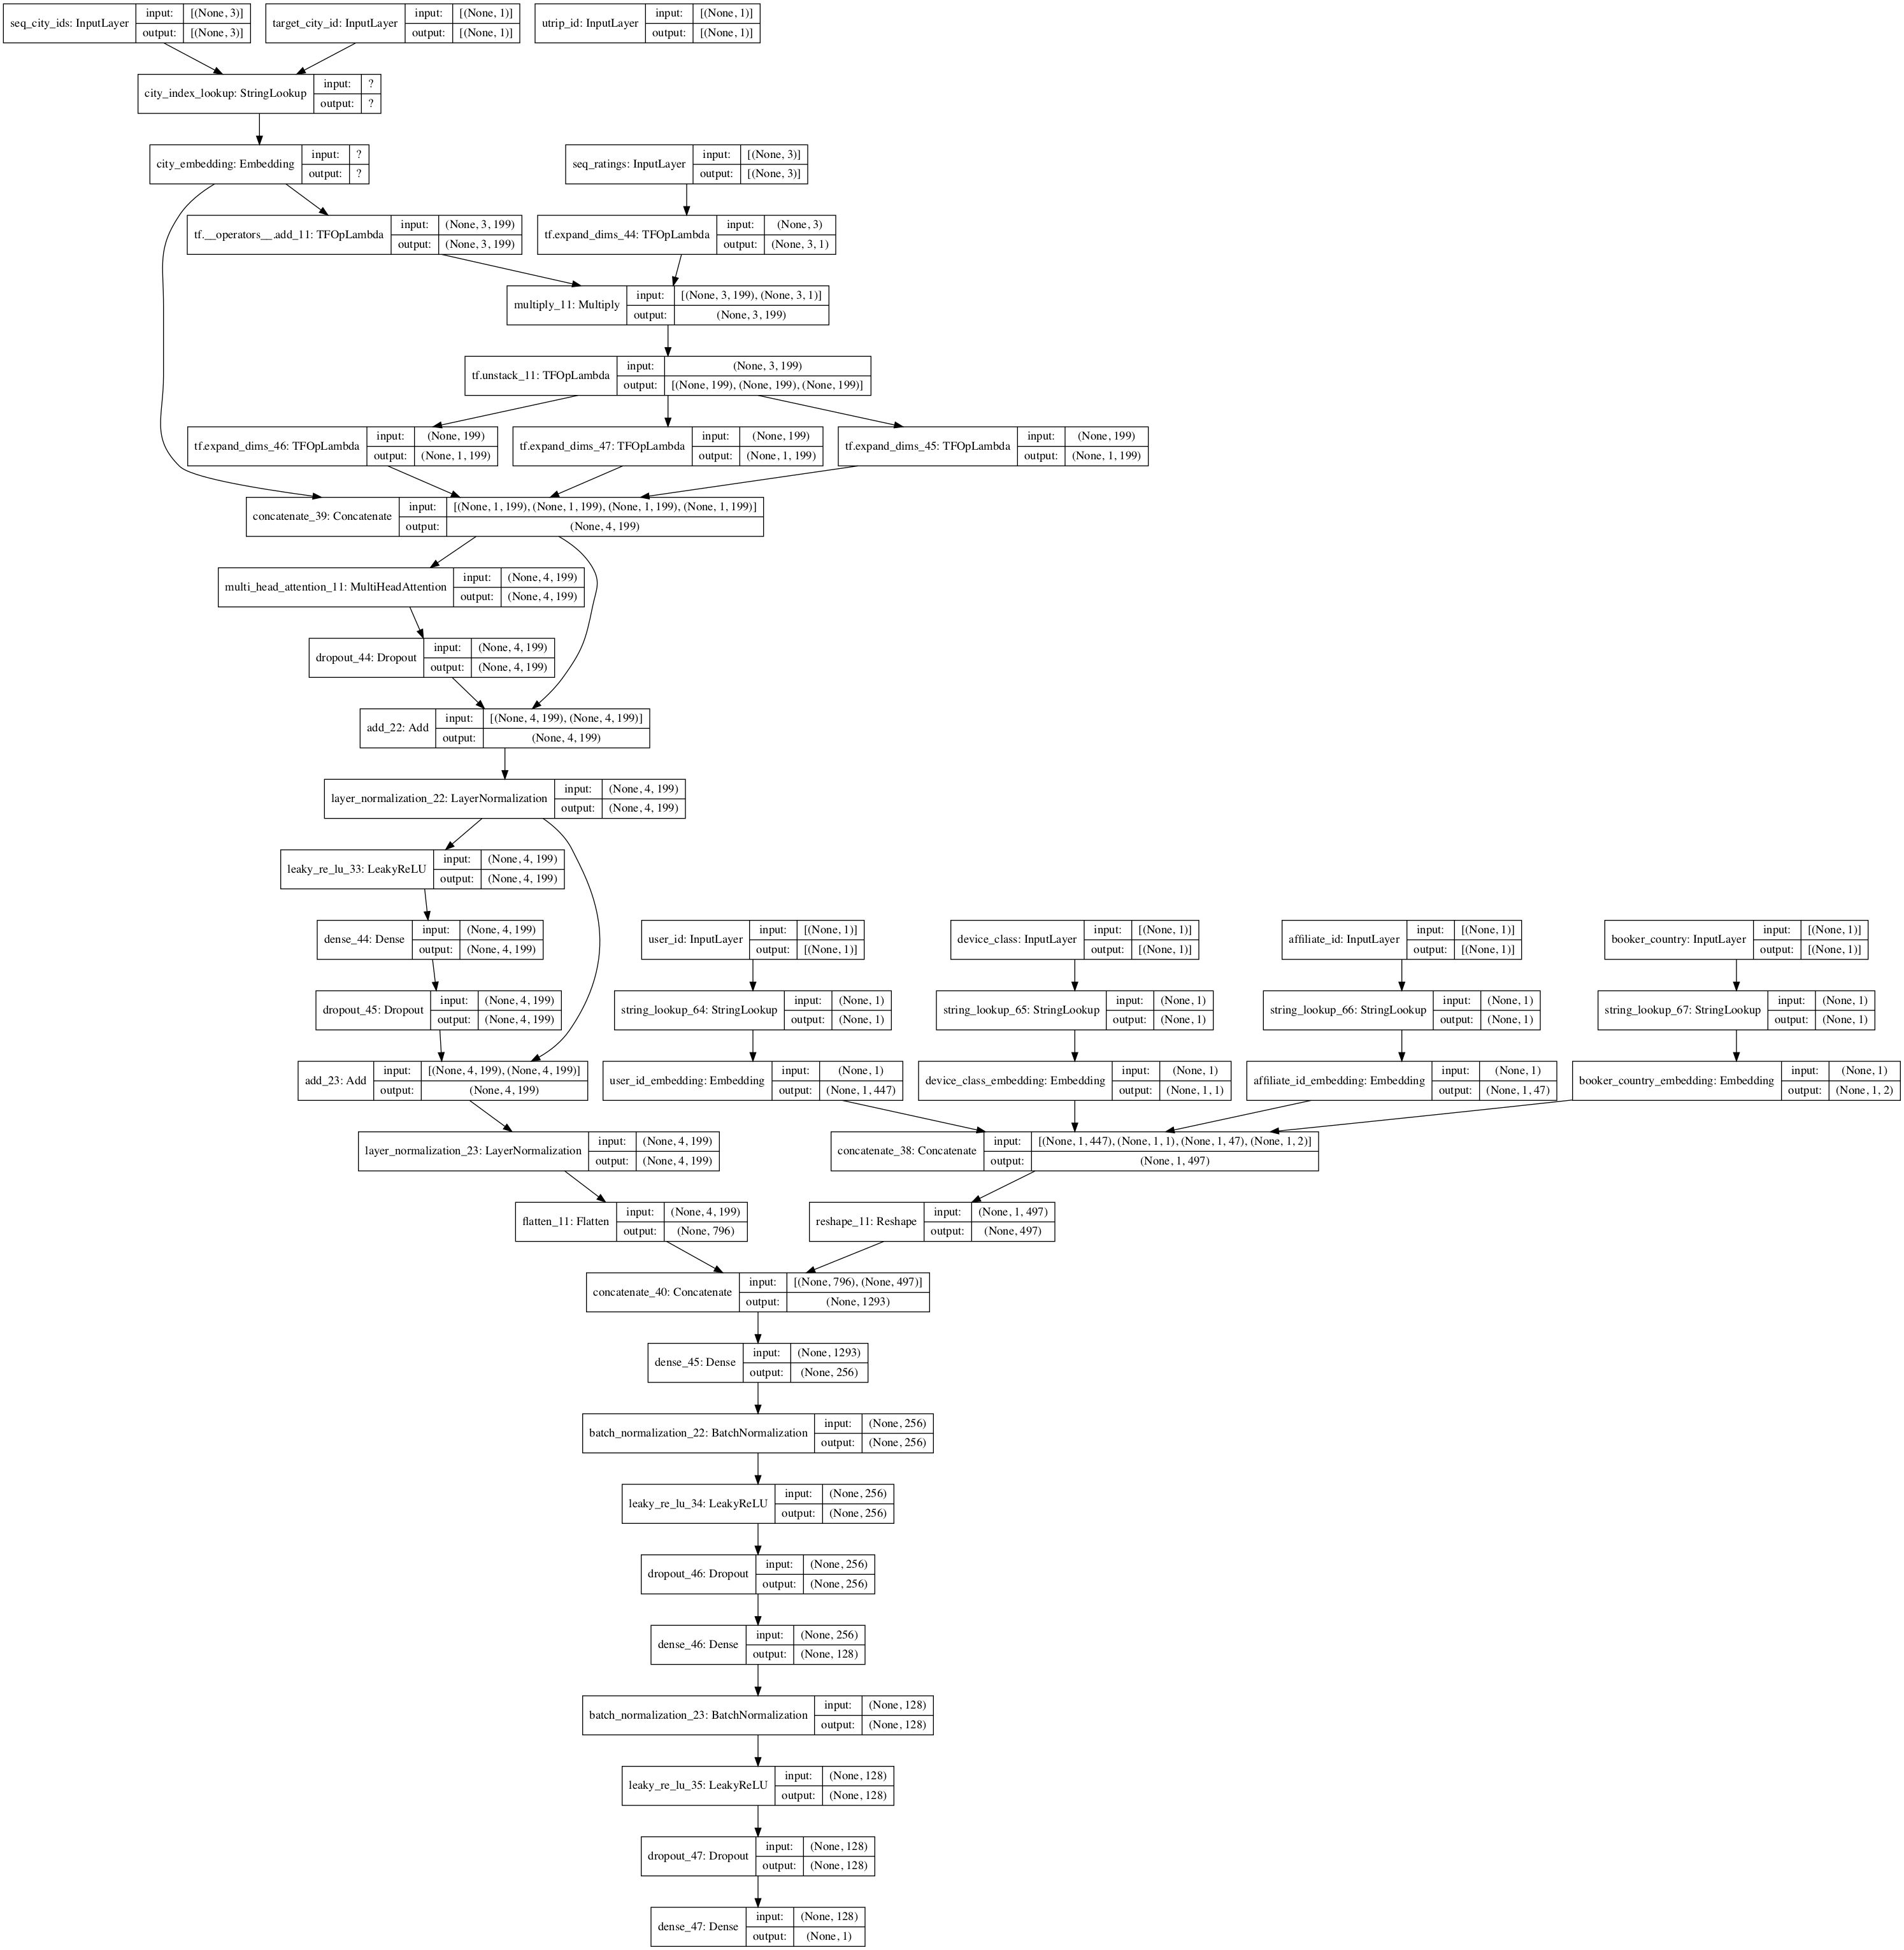

In [364]:
from tensorflow.keras.utils import plot_model

plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)


In [365]:
# Read the training data.
train_dataset = get_dataset_from_csv("train_data.csv", shuffle=True, batch_size=265)
#train_dataset = train_data

# Fit the model with the training data.
model.fit(train_dataset, epochs=5)

Epoch 1/5


/Users/nitinrawat/anaconda3/lib/python3.8/site-packages/tensorflow/python/keras/engine/functional.py:592: UserWarning: Input dict contained keys ['seq_time'] which did not match any model input. They will be ignored by the model.
  warnings.warn(


1297/1297 [==============================] - 45s 34ms/step - loss: 1.3565 - mean_absolute_error: 0.7897
Epoch 2/5
1297/1297 [==============================] - 47s 36ms/step - loss: 1.0976 - mean_absolute_error: 0.6930
Epoch 3/5
1297/1297 [==============================] - 47s 36ms/step - loss: 1.0425 - mean_absolute_error: 0.6736
Epoch 4/5
1297/1297 [==============================] - 46s 36ms/step - loss: 1.0073 - mean_absolute_error: 0.6609
Epoch 5/5
1297/1297 [==============================] - 47s 36ms/step - loss: 0.9740 - mean_absolute_error: 0.6500


In [367]:
model.save('model')

INFO:tensorflow:Assets written to: model/assets


INFO:tensorflow:Assets written to: model/assets


In [368]:
# Read the test data.
test_dataset = get_dataset_from_csv("test_data.csv", batch_size=265)

# Evaluate the model on the test data.
_, rmse = model.evaluate(test_dataset, verbose=0)
print(f"Test MAE: {round(rmse, 3)}")

/Users/nitinrawat/anaconda3/lib/python3.8/site-packages/tensorflow/python/keras/engine/functional.py:592: UserWarning: Input dict contained keys ['seq_time'] which did not match any model input. They will be ignored by the model.
  warnings.warn(


Test MAE: 0.655


In [391]:
ratings = model.predict(test_dataset)

In [395]:
def get_testset_from_csv(csv_file_path, shuffle=False, batch_size=128, target_city=0):
    def process(features):
        city_ids_string = features["seq_city_ids"]
        sequence_city_ids = tf.strings.split(city_ids_string, ",").to_tensor()

        # The last movie id in the sequence is the target movie.
        features["target_city_id"] = target_city
        features["seq_city_ids"] = sequence_city_ids[:, :]

        ratings_string = features["seq_ratings"]
        sequence_ratings = tf.strings.to_number(
            tf.strings.split(ratings_string, ","), tf.dtypes.float32
        ).to_tensor()

        # The last rating in the sequence is the target for the model to predict.
        target = None
        features["seq_ratings"] = sequence_ratings[:, :]

        return features, target

    dataset = tf.data.experimental.make_csv_dataset(
        csv_file_path,
        batch_size=batch_size,
        column_names=CSV_HEADER,
        num_epochs=1,
        header=False,
        field_delim="|",
        shuffle=shuffle,
    ).map(process)

    return dataset

In [396]:
for city in CATEGORICAL_FEATURES_WITH_VOCABULARY['city_id']:
    print (city)
    ex = get_testset_from_csv("test_data_sample.csv", batch_size=265, target_city=city)
    pred = model.predict(ex)
    print (pred)
    break

city_31114


ValueError: in user code:

    /Users/nitinrawat/anaconda3/lib/python3.8/site-packages/tensorflow/python/keras/engine/training.py:1478 predict_function  *
        return step_function(self, iterator)
    /Users/nitinrawat/anaconda3/lib/python3.8/site-packages/tensorflow/python/keras/engine/training.py:1468 step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    /Users/nitinrawat/anaconda3/lib/python3.8/site-packages/tensorflow/python/distribute/distribute_lib.py:1259 run
        return self._extended.call_for_each_replica(fn, args=args, kwargs=kwargs)
    /Users/nitinrawat/anaconda3/lib/python3.8/site-packages/tensorflow/python/distribute/distribute_lib.py:2730 call_for_each_replica
        return self._call_for_each_replica(fn, args, kwargs)
    /Users/nitinrawat/anaconda3/lib/python3.8/site-packages/tensorflow/python/distribute/distribute_lib.py:3417 _call_for_each_replica
        return fn(*args, **kwargs)
    /Users/nitinrawat/anaconda3/lib/pyt

In [387]:
ex = get_testset_from_csv("test_data_sample.csv", batch_size=265)

In [388]:
ex

<MapDataset shapes: (OrderedDict([(utrip_id, (None,)), (seq_city_ids, (None,)), (seq_ratings, (None, None)), (seq_time, (None,)), (user_id, (None,)), (device_class, (None,)), (affiliate_id, (None,)), (booker_country, (None,)), (target_city_id, (39902,))]), NoneTensorSpec()), types: (OrderedDict([(utrip_id, tf.string), (seq_city_ids, tf.string), (seq_ratings, tf.float32), (seq_time, tf.string), (user_id, tf.string), (device_class, tf.string), (affiliate_id, tf.string), (booker_country, tf.string), (target_city_id, tf.string)]), NoneTensorSpec())>

In [389]:
ex.element_spec

(OrderedDict([('utrip_id',
               TensorSpec(shape=(None,), dtype=tf.string, name=None)),
              ('seq_city_ids',
               TensorSpec(shape=(None,), dtype=tf.string, name=None)),
              ('seq_ratings',
               TensorSpec(shape=(None, None), dtype=tf.float32, name=None)),
              ('seq_time',
               TensorSpec(shape=(None,), dtype=tf.string, name=None)),
              ('user_id',
               TensorSpec(shape=(None,), dtype=tf.string, name=None)),
              ('device_class',
               TensorSpec(shape=(None,), dtype=tf.string, name=None)),
              ('affiliate_id',
               TensorSpec(shape=(None,), dtype=tf.string, name=None)),
              ('booker_country',
               TensorSpec(shape=(None,), dtype=tf.string, name=None)),
              ('target_city_id',
               TensorSpec(shape=(39902,), dtype=tf.string, name=None))]),
 NoneTensorSpec())

In [390]:
model.predict(ex)

InvalidArgumentError:  Incompatible shapes: [2,3,199] vs. [2,4,1]
	 [[node model_11/multiply_11/mul (defined at <ipython-input-386-ab71110f7079>:1) ]] [Op:__inference_predict_function_53558]

Function call stack:
predict_function
